# ES3J1 Advanced Systems and Software Engineering

## Python Assignment 2025–2026

*Reproducible run — RNG seeded below.*

## Reproducibility

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Random number generator seed fixed for reproducibility
np.random.seed(0)

## Q1 — Mathematical Model

Newton's second law gives $m\ddot{q} = G + u$. Defining momentum $p = m\dot{q}$ yields $\dot{q} = p/m$ and $\dot{p} = G + u$. With state $x = (q, p)$ this gives $\dot{x} = Ax + B(G + u)$, where

$$
A =
\begin{pmatrix}
0 & 0 & 1/m & 0 \\
0 & 0 & 0 & 1/m \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{pmatrix},
\qquad
B =
\begin{pmatrix}
0 & 0 \\
0 & 0 \\
1 & 0 \\
0 & 1
\end{pmatrix}.
$$

For free fall from rest, $v_{\text{impact}} = \sqrt{2gh}$, giving $h_{\max} = 10^2/(2g) \approx 13.51$ m. For $h_{\text{safe}} = 5$ m, $v \approx 6.08$ m/s $< 10$ m/s, confirming a safe landing.

In [89]:
## Physical constants provided
m = 2.0   # drone mass in kg
g = 3.7   # Martian gravitational acceleration in m/s^2
h_safe = 5.0   # height in m

## Gravity acts in the negative z-direction with m * g and x component is 0.
G = np.array([0.0, - m * g])

## State-space matrix A shows the relation dot(q) = p/m.
A_drone = np.array([
    [0.0, 0.0, 1.0 / m, 0.0    ],
    [0.0, 0.0, 0.0,     1.0 / m],
    [0.0, 0.0, 0.0,     0.0    ],
    [0.0, 0.0, 0.0,     0.0    ]
])

## Input matrix B maps the 2-d force vector (G + u)
B_drone = np.array([
    [0.0, 0.0],
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0]
])

## Maximum safe drop height from v^2 = 2 g h  => h_max = v_max^2 / (2g)
h_max = (10.0 ** 2) / (2.0 * g)
print(f"Maximum safe drop height: h_max = {h_max:.4f} m")
print(f"Impact speed from h_safe = 5: v = {np.sqrt(2.0 * g * h_safe):.4f} m/s")
print(f"h_safe = {h_safe:.1f} m is safe? {'Yes' if h_safe <= h_max else 'No'}")

Maximum safe drop height: h_max = 13.5135 m
Impact speed from h_safe = 5: v = 6.0828 m/s
h_safe = 5.0 m is safe? Yes


## Q2 — Numerical Solution of the State-Space Model

### Implicit (backward) Euler scheme

The dynamics are given by $( \dot{x} = A x + B(G + u(t)) )$.  

Applying the implicit Euler scheme with timestep $( \Delta t )$
gives
$$[
(I - \Delta t\,A)x_{i} = x_{i-1} + \Delta t\,B(G + u_i)
]$$

such that
$$[
x_i = F x_{i-1} + \Gamma (G + u_i),
]$$

where $( F = (I - \Delta t A)^{-1} )$ and $( \Gamma = \Delta t\,F B )$.

As $( A )$ is constant, $( F )$ and \( $Gamma$ ) are already calculated, it makes this process quick and effecient.

Implicit Euler is unconditionally stable for linear systems which makes it apt for this gravity dependent problem.


In [90]:
## Fixed time step and initial time (seconds)
dt = 0.05
t0 = 0.0

I4 = np.eye(4)   ## 4x4 identity matrix

## Compute the implicit Euler propagator F = (I - dt * A)^-1.
F_prop = np.linalg.solve(I4 - dt * A_drone, I4)

## Gamma = dt * F * B
Gam_mat = dt * F_prop @ B_drone

def in_forbidden_region(q):
    # This function returns True if the position vector q is in the forbidden region and False if it is not

    return (25.0 <= q[0] <= 75.0) and (0.0 <= q[1] <= 200.0)

def impact_speed(x_state):
    # Returns the euclidean speed (||v|| = ||p / m||) of x_state
    return np.linalg.norm(x_state[2:] / m)

def step_implicit_euler(x_state, u):
    # This function advances the state by one implicit euler step. This is done using the pre-computed F_prop and Gam_mat

    return F_prop @ x_state + Gam_mat @ (G + u)

In [91]:
def simulate_drone(x_init, t_end, control_fn = None):
    # This function essentially simulates the drone from initial state to time end with implicit Euler step
    # control_fn essentially controls what force is to be applied at each step, in this case, it is set to 0
    # The simulation records the safety of the landing and entry into the forbidden region and terminates upon ground impact
    '''
      The simulation outputs
            times             : 1-d array of recorded times
            states            : array of shape (N, 4)
            controls          : array of shape (N, 2)
            entered_forbidden : bool
            forbidden_time    : float or none
            impact_time       : float or none
            safe_landing      : bool or none
    '''
    ## Total number of steps from start(t0) to finish(t_end) with step size dt
    n_steps = int(round((t_end - t0) / dt))

    ## Initialise the lists with their initial states
    times = [t0]
    states = [x_init.copy()]
    controls = [np.zeros(2)]

    ## Initialise event detection variables
    entered_forbidden = False
    forbidden_time = None
    impact_time = None
    safe_landing = None

    x = x_init.copy()   ## copy of the current state

    for n in range(n_steps):
        t = t0 + (n + 1) * dt

        ## Checks the control force at the current time and state. If no controller is supplied, force is u = 0 (free fall).
        u = control_fn(t, x) if control_fn is not None else np.zeros(2)

        ## Moves the state by one implicit Euler step
        x = step_implicit_euler(x, u)

        ## Checks if and when the drone has entered the forbidden region.
        if in_forbidden_region(x[:2]) and not entered_forbidden:
            entered_forbidden = True
            forbidden_time = t

        ## Checks for ground impact
        # this prevents any logical error of the drone going 'underground' and also records the ground impact data
        if x[1] <= 0.0:
            x[1] = 0.0
            impact_time = t
            safe_landing = (impact_speed(x) <= 10.0)
            times.append(t)
            states.append(x.copy())
            controls.append(u.copy())
            break

        times.append(t)
        states.append(x.copy())
        controls.append(u.copy())

    return {
        "times":             np.array(times),
        "states":            np.array(states),
        "controls":          np.array(controls),
        "entered_forbidden": entered_forbidden,
        "forbidden_time":    forbidden_time,
        "impact_time":       impact_time,
        "safe_landing":      safe_landing,
    }

In [92]:
## Initial conditions from the assignment brief
q0 = np.array([0.0, 100.0])   # initial position m
v0 = np.array([8.0, 1.0])   # initial velocity  (m/s)
p0 = m * v0  # initial momentum (kg m/ s)
x0 = np.concatenate([q0, p0])  # initial state vector

# Run the uncontrolled simulation with u(t) = 0
sim_q2    = simulate_drone(x0, t_end = 10.0)
times_q2  = sim_q2["times"]
states_q2 = sim_q2["states"]

## Return the  key outcomes
print(f"Impact time: {sim_q2['impact_time']:.3f} s")
print(f"Impact speed: {impact_speed(states_q2[-1]):.4f} m/s ")
print(f"Safe landing? {sim_q2['safe_landing']}")
print(f"Entered forbidden region? {sim_q2['entered_forbidden']}")
if sim_q2["forbidden_time"] is not None:
    print(f"First forbidden entry at:  {sim_q2['forbidden_time']:.2f} s")

Impact time: 7.650 s
Impact speed: 28.4528 m/s 
Safe landing? False
Entered forbidden region? True
First forbidden entry at:  3.15 s


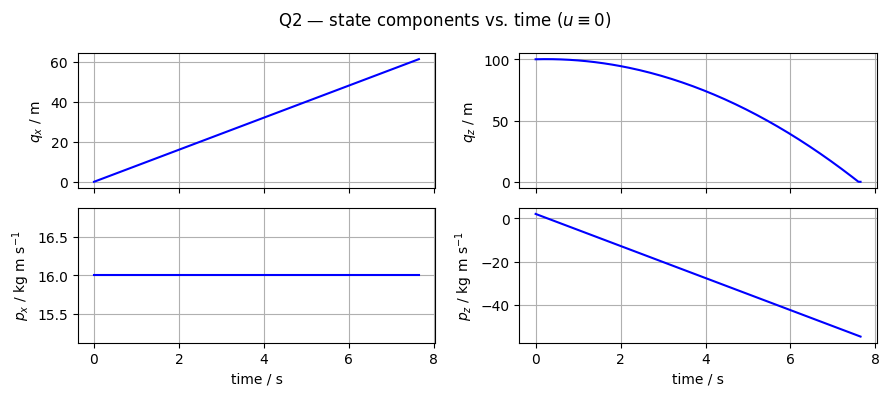

In [93]:
## Plot the four state components against time.
state_labels = ["$q_x$ / m", "$q_z$ / m",
                "$p_x$ / kg m s$^{-1}$", "$p_z$ / kg m s$^{-1}$"]

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (9, 4), sharex = True)

for i in range(4):
    r, c = divmod(i, 2)
    ax[r, c].plot(times_q2, states_q2[:, i], color = "blue")
    ax[r, c].set_ylabel(state_labels[i])
    ax[r, c].grid()
    if r == 1:
        ax[r, c].set_xlabel("time / s")

fig.suptitle(r"Q2 — state components vs. time ($u \equiv 0$)");
plt.tight_layout()
plt.show()

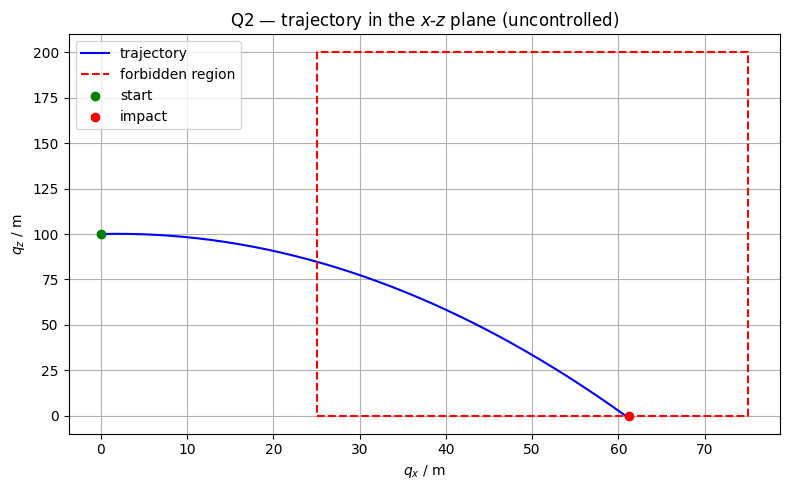

In [94]:
## Plots the trajectory in the x-z plane with the forbidden region boundary.
## The forbidden box is drawn as a red rectangle.
forbidden_x = [25, 75, 75, 25, 25]
forbidden_z = [ 0,  0, 200, 200,  0]

fig, ax = plt.subplots(figsize = (8, 5))
ax.plot(states_q2[:, 0], states_q2[:, 1], color = "blue",  label = "trajectory")
ax.plot(forbidden_x, forbidden_z, color = "red", linestyle = "--", label = "forbidden region")
ax.scatter([states_q2[ 0, 0]], [states_q2[ 0, 1]], color = "green", zorder = 5, label = "start")
ax.scatter([states_q2[-1, 0]], [states_q2[-1, 1]], color = "red",   zorder = 5, label = "impact")
ax.set_xlabel("$q_x$ / m")
ax.set_ylabel("$q_z$ / m")
ax.set_title("Q2 — trajectory in the $x$-$z$ plane (uncontrolled)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

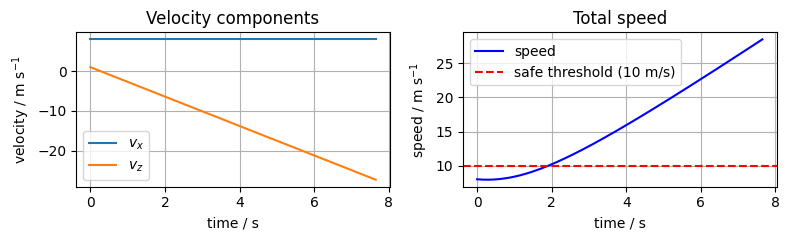

In [95]:
## Speed of the drone plotted
## The horizontal dashed line is the safe-landing speed threshold.

vel_q2 = states_q2[:, 2:] / m            # velocity = momentum / mass
speed_q2 = np.linalg.norm(vel_q2, axis=1)  # Euclidean speed at each point

fig, ax = plt.subplots(1, 2, figsize = (8, 2.5))

ax[0].plot(times_q2, vel_q2[:, 0], label = "$v_x$")
ax[0].plot(times_q2, vel_q2[:, 1], label = "$v_z$")
ax[0].set_xlabel("time / s")
ax[0].set_ylabel("velocity / m s$^{-1}$")
ax[0].set_title("Velocity components")
ax[0].grid()
ax[0].legend()

ax[1].plot(times_q2, speed_q2, color = "blue", label = "speed")
ax[1].axhline(10.0, color = "red", linestyle = "--", label = "safe threshold (10 m/s)")
ax[1].set_xlabel("time / s")
ax[1].set_ylabel("speed / m s$^{-1}$")
ax[1].set_title("Total speed")
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

### Q2 — Discussion

 The trajectory of the drone follows the expected free-fall path. The x-momentum is constant as there is no horizontal force while the z-momentum decreases linearly at rate  -7.4 N (-mg). The drone impacts the ground at approximately 7.65s which is consistent with the expected range of 6–8 s. The impact speed is approximately 28.5 m/s which is greater than the 10 m/s safety threshold thus making the landing unsafe. The trajectory also passes through the forbidden region. This confirms that the uncontrolled system fails both safety and forbidden region requirements set for the simulation.

## Q3 — Linear Kalman Filter

At each integer time, a noisy position observation $y_k = Hx(t_k) + \varepsilon_k$, $\varepsilon_k \sim \mathcal{N}(0,R)$ is available, with $H = \bigl(\begin{smallmatrix}1&0&0&0\\0&1&0&0\end{smallmatrix}\bigr)$ and $R = (0.25)^2 I_2$. Momentum must be inferred from the dynamics.

The implicit Euler scheme gives $x_{n+1} = F_{\text{prop}}x_n + \Gamma(G+u_n)$. The Kalman recursion forecasts

$$\tilde{m}_{n+1} = F_{\text{prop}}m_n + \Gamma(G+u_n), \qquad \tilde{C}_{n+1} = F_{\text{prop}}C_n F_{\text{prop}}^\top$$

and updates at observation times via $m_{n+1} = \tilde{m}_{n+1} + K(y_{n+1} - H\tilde{m}_{n+1})$, $C_{n+1} = (I-KH)\tilde{C}_{n+1}$, with gain of $K = \tilde{C}_{n+1}H^\top(H\tilde{C}_{n+1}H^\top + R)^{-1}$. The filter is initialised at $m_0 = 0$, $C_0 = 10^8 I_4$.

In [96]:
## Observation matrix which extracts the position components q_x and q_z
H_obs = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0]
])

## Observation noise covariance => independent Gaussian noise with standard deviation 0.25 m .
R_obs = (0.25 ** 2) * np.eye(2)


def run_kalman_filter(true_states, true_times, control_sequence = None):
    # Linear Kalman filter  set for the drone model
    '''
        true_states : array of shape (N, 4) (true state trajectory)
        true_times : 1-d array of length N (corresponding times)
        control_sequence : array of shape (N-1, 2), or None for u = 0 (Forces used for predictions)

        Observations are generated at each integer time by adding gaussian noise to the true position.

        Returns a dict with:
            means        : array of (N, 4) (Estimated state mc)
            covs         : list of N covariance matrices (Uncertainity matrices)
            observations : array (N, 2) (noisy measurents)
            obs_mask     : bool array of length N (checks whether observations exist)
    '''
    N = len(true_times)
    if control_sequence is None:
        control_sequence = np.zeros((N - 1, 2))

    # Initialise with incorrect mean and large covariance
    m_c = np.zeros(4)
    C_c = 1.0e8 * np.eye(4)

    #  Crete copies of initial state
    means = [m_c.copy()]
    covs = [C_c.copy()]
    observations = [np.full(2, np.nan)]
    obs_mask = [False]

    for k in range(N - 1):
        u = control_sequence[k]

        ## Forecast Step => this uses the forces G & u to predict where it will be next

        m_pred = F_prop @ m_c + Gam_mat @ (G + u)
        C_pred = F_prop @ C_c @ F_prop.T

        t_next = true_times[k + 1]

      ##  Analysis step => specififically at integer times

        if np.isclose(t_next % 1.0, 0.0):

            # Producing a noisy reading of the true position
            y = H_obs @ true_states[k + 1] + np.random.normal(0.0, 0.25, size = 2)

            # Innovation covariance calculation (S = H C_pred H^T + R)
            S = H_obs @ C_pred @ H_obs.T + R_obs

            # Calculating Kalman gain (K = C_pred H^T / S)
            K = np.linalg.solve(S.T, (C_pred @ H_obs.T).T).T

            # Update mean based on how wrong it is essentially
            m_c = m_pred + K @ (y - H_obs @ m_pred)

            # Update covariance based on the new information
            C_c = (I4 - K @ H_obs) @ C_pred
            observations.append(y.copy())
            obs_mask.append(True)

        else:
            ## if no observation available => the forecast moves forward
            m_c = m_pred
            C_c = C_pred
            observations.append(np.full(2, np.nan))
            obs_mask.append(False)

        means.append(m_c.copy())
        covs.append(C_c.copy())

    return {
        "means":np.array(means),
        "covs":covs,
        "observations":np.array(observations),
        "obs_mask":np.array(obs_mask, dtype = bool),
    }

In [97]:
## Run the Kalman filter on the Q2 uncontrolled trajectory
kf_q3 = run_kalman_filter(states_q2, times_q2)
means_q3 = kf_q3["means"]
covs_q3 = kf_q3["covs"]
obs_q3 = kf_q3["observations"]
obs_mask_q3 = kf_q3["obs_mask"]

## The differene between predictive estimates and actual values at each time step
errors_q3 = means_q3 - states_q2

## Extract +-1 standard deviation from covariance matrix. This helps identify the uncertainity of the filter at each step
std_q3 = np.array([np.sqrt(np.diag(C)) for C in covs_q3])

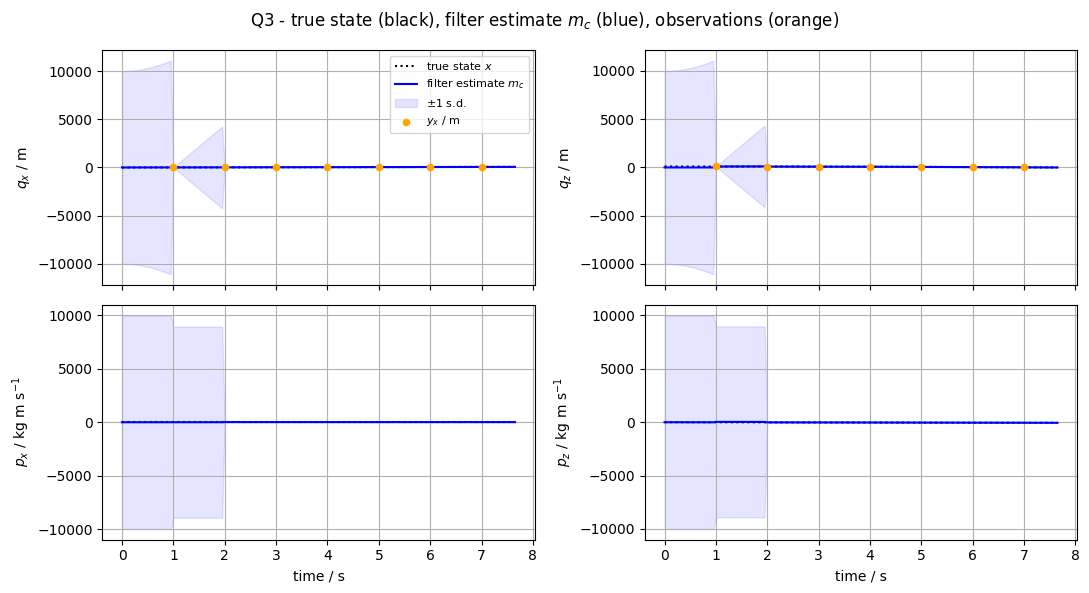

In [98]:
## Plot 1: true state (black dashed), filter estimate (blue) and observations (orange).
## Observations only exist for q_x and q_z so no estimates or predictions for the others

obs_times = times_q2[obs_mask_q3]
obs_labels = ["$y_x$ / m", "$y_z$ / m"]
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (11, 6), sharex = True)

for i in range(4):
    r, c = divmod(i, 2)
    ax[r, c].plot(times_q2, states_q2[:, i], ":", color = "black", label = "true state $x$")
    ax[r, c].plot(times_q2, means_q3[:, i],       color = "blue",  label = "filter estimate $m_c$")
    ax[r, c].fill_between(
        times_q2,
        means_q3[:, i] - std_q3[:, i],
        means_q3[:, i] + std_q3[:, i],
        alpha = 0.1, color = "blue", label = r"$\pm 1$ s.d.")
    ## The noisy position observations (orange dots)
    ax[r, c].set_ylabel(state_labels[i])
    ax[r, c].grid()
    if i < 2:
        ax[r, c].scatter(obs_times, obs_q3[obs_mask_q3, i], color = "orange", s = 20, zorder = 5, label = obs_labels[i])
    if i == 0:
        ax[r, c].legend(fontsize = 8)
    if r == 1:
        ax[r, c].set_xlabel("time / s")
fig.suptitle("Q3 - true state (black), filter estimate $m_c$ (blue), observations (orange)");
plt.tight_layout()
plt.show()

/tmp/ipykernel_1782/2103064044.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


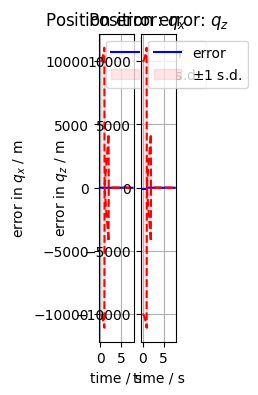

In [99]:
## Plot 2: zoomed prediction errors m_c - x with +-1 stanndard deviation.
## The large initial error is due to the initial mean m_c set as 0 and after a few observations the filter corrects itself.
fig, ax = plt.subplots(1, 2, figsize = (1, 4), sharex = True)

for i, label in enumerate(["$q_x$", "$q_z$"]):
    ax[i].plot(times_q2, errors_q3[:, i], color = "blue",  label = "error")
    ax[i].plot(times_q2,  std_q3[:, i],   color = "red", linestyle = "--")
    ax[i].plot(times_q2, -std_q3[:, i],   color = "red", linestyle = "--")
    ax[i].fill_between(times_q2, -std_q3[:, i], std_q3[:, i], alpha = 0.1, color = "red", label = r"$\pm 1$ s.d.")
    ax[i].set_xlabel("time / s")
    ax[i].set_ylabel(f"error in {label} / m")
    ax[i].set_title(f"Position error: {label}")
    ax[i].grid()
    ax[i].legend()

plt.tight_layout()
plt.show()

### Q3 Discussion

The filter begins with the preset incorrect mean and large covariance, so the initial uncertainty bands are very large as well. At the first observation (t=1s), the Kalman gain is large and the estimate is rapidly corrected. The filter quickly adjusts to the the true state and the uncertainty reduces just as quickly as well. The position components are observed so their errors reduce rapidly after the first few observations. The momentum components are not observed so they are determined through the dynamics but they also reduce quickly due to the deterministic model. The ±1 standard deviation bands represent the filter’s uncertainty. These are initially very large and then shrink rapidly as the time progresses. The prediction error remains small and within the confidence bands which indicates that the filter is stable and consistent. The rapid collapse of uncertainty reflects the deterministic nature of the system (no system noise or randomness) and the small observation noise.

## Q4 — Feedback Control and Safe Landing

A proportional–derivative (PD) feedback controller is based on the Kalman estimate $m_c$. The desired net force is $G + u = k_q(q^* - m_q^c) + k_p(p^* - m_p^c)$, giving the control input $u = k_q(q^* - m_q^c) + k_p(p^* - m_p^c) - G$, clipped to $\|u\| \leq 15$ N. The gains $k_q = 0.3$ and $k_p = 0.8$ move the drone towards the target while providing damping to prevent overshooting.

To avoid the forbidden region $[25,75] \times [0,200]$, the drone follows three waypoints: $(0,210) \rightarrow (100,210) \rightarrow (100,5)$, advancing when $\|m_q^c - q^*\| < 1$ m and $\|v\| < 0.5$ m s$^{-1}$. At the final waypoint $(100,5)$, the drone holds within 3 m at speed below 1 m s$^{-1}$ for 5 s, after which control is set to 0 and the drone falls freely. From Q1, a drop from 5 m ensures a safe landing.

In [100]:
## Control gains and constraints given
kq = 0.3    # position gain => how much the drone move towards target point q*
kp = 0.8    # momentum gain => how much should the movement be damped and it prevents the drone from overshooting the target
u_max = 15.0   # maximum control force applied (N)

## Waypoints have 4-d target states: (q_x*, q_z*, p_x*, p_z*) and the drone is set to be stop and rest at each waypoint as well
# if the 3 set waypoints are followed by the drone it ensures that it avoids the forbidden region
waypoints = [
    np.array([  0.0, 210.0, 0.0, 0.0]),  # (1) above forbidden box
    np.array([100.0, 210.0, 0.0, 0.0]),  # (2) right above the landing site
    np.array([100.0, h_safe, 0.0, 0.0]), ## (3) final hover point
]

def clip_control(u):
  # This function ensures that the control force does not exceed the max value by rescaling it
    norm_u = np.linalg.norm(u)
    if norm_u > u_max:
        return u_max * u / norm_u
    return u

def pd_control(m_c, x_target):
  # This function focuses on feedback control using kalman filter estimate.
  # The below equation adjusts the net force so the drone moves towards the target(q*) while slowing down (p = 0).
  # Desired net force:  G + u = kq*(q* - q_est) + kp*(p* - p_est)
  # the u(control force) is made to account for the gravity in the system as well
  # u  = kq*(q* - q_est) + kp*(p* - p_est) - G

    q_err = x_target[:2] - m_c[:2]   # position error compared to estimate
    p_err = x_target[2:] - m_c[2:]   # momentum error compared to estimate

    ## Desired net force subtracting gravity will get the control force
    desired_net_force = kq * q_err + kp * p_err
    u = desired_net_force - G
    return clip_control(u)

In [101]:
def simulate_controlled_flight(x_init, t_end):
# this simulates the drones dynamics with the kalman filter estimate and
# uses the wapoint dependent feedback controller for the drones movement
# the control uses the kalman estimate m_c to go through various phases which are
# the 3 waypoints, hovering over the ground and when the drone falls to the ground

    n_steps = int(round((t_end - t0) / dt))

    ## set the true state from the initial conditions
    x_true = x_init.copy()

    ## Initialise the Kalman filter with incorrect mean and large covariance
    m_c = np.zeros(4)
    C_c = 1.0e8 * np.eye(4)

    ## Initialise output lists with start position values
    times        = [t0]
    true_states  = [x_true.copy()]
    est_states   = [m_c.copy()]
    covs         = [C_c.copy()]
    controls     = [np.zeros(2)]
    observations = [np.full(2, np.nan)]
    obs_mask     = [False]
    phases       = [0]

    ## Phase tracking variables
    wp_index   = 0      # current waypoint count
    hover_time = 0.0    # time hovered so it can be checked if it 5 second standards
    released   = False  # used for final phase for free fall off drone

    ## Event flags
    impact_time = None
    safe_landing = None
    entered_forbidden = False
    forbidden_time = None

    for n in range(n_steps):
        t = t0 + (n + 1) * dt

        # This if condition determines the control force (u) based on the kalman estimate
        # After phase 4, the control force is set to 0 so the drone can free fall
        if released:
            u = np.zeros(2)
            phase = 4
        else:
            x_target = waypoints[wp_index]
            u = pd_control(m_c, x_target)
            phase = wp_index

        ## Increment the true state by one Euler step
        x_true = step_implicit_euler(x_true, u)

        ## Check if the true trajectory enters the forbidden region
        if in_forbidden_region(x_true[:2]) and not entered_forbidden:
            entered_forbidden = True
            forbidden_time = t

        # Checking for ground impact of the drone
        if x_true[1] <= 0.0:
            x_true[1] = 0.0
            impact_time = t
            safe_landing = (impact_speed(x_true) <= 10.0)

        ## Kalman filter forecast step
        m_pred = F_prop @ m_c + Gam_mat @ (G + u)
        C_pred = F_prop @ C_c @ F_prop.T

        ## This uses the kalman filter to updates the values at each integer time
        if np.isclose(t % 1.0, 0.0):
            y = H_obs @ x_true + np.random.normal(0.0, 0.25, size = 2)
            S = H_obs @ C_pred @ H_obs.T + R_obs
            K = np.linalg.solve(S.T, (C_pred @ H_obs.T).T).T
            m_c = m_pred + K @ (y - H_obs @ m_pred)
            C_c = (I4 - K @ H_obs) @ C_pred
            observations.append(y.copy())
            obs_mask.append(True)
        else:
            m_c = m_pred
            C_c = C_pred
            observations.append(np.full(2, np.nan))
            obs_mask.append(False)

        ## This is crucial as it tells the drone which waypoint its headed to
        if not released:
            x_target = waypoints[wp_index]

            if wp_index < len(waypoints) - 1:
                # Advance to the next waypoint as estimate for position < 1 m and speed < 0.5 m/s
                # The position and speed thresholds were determined based on smooth movement while hitting all the waypoints succesfully
                pos_close  = np.linalg.norm(m_c[:2] - x_target[:2]) < 1.0
                speed_slow = np.linalg.norm(m_c[2:] / m) < 0.5
                if pos_close and speed_slow:
                    wp_index += 1
            else:
                # This is to hover at the phase 4. It has conditions to ensure the drone doesnt drift more than 3 m
                # and has a speed of less than 1m/s for a good 5s hold

                near_hover = (np.linalg.norm(m_c[:2] - x_target[:2]) < 3.0
                              and np.linalg.norm(m_c[2:] / m) < 1.0)
                if near_hover:
                    hover_time += dt
                else:
                    hover_time  = 0.0

                ## Once 5 seconds of hovering is complete, control force is made 0
                if hover_time >= 5.0:
                    released = True

        # Store results for the step
        times.append(t)
        true_states.append(x_true.copy())
        est_states.append(m_c.copy())
        covs.append(C_c.copy())
        controls.append(u.copy())
        phases.append(phase)

        if impact_time is not None:
            break # the drone has landed

    return {
        "times": np.array(times),
        "true_states": np.array(true_states),
        "est_states": np.array(est_states),
        "covs": covs,
        "controls": np.array(controls),
        "observations": np.array(observations),
        "obs_mask": np.array(obs_mask, dtype = bool),
        "phases": np.array(phases),
        "impact_time": impact_time,
        "safe_landing": safe_landing,
        "entered_forbidden": entered_forbidden,
        "forbidden_time": forbidden_time,
        "hover_time": hover_time,
    }

sim_q4 = simulate_controlled_flight(x0, t_end = 200.0)
times_q4 = sim_q4["times"]
states_q4 = sim_q4["true_states"]
ests_q4 = sim_q4["est_states"]
controls_q4 = sim_q4["controls"]

## Report all the outcomes
print(f"Impact time: {sim_q4['impact_time']:.2f} s")
print(f"Impact speed: {impact_speed(states_q4[-1]):.4f} m/s ")
print(f"Safe landing?  {sim_q4['safe_landing']}")
print(f"Final position: {states_q4[-1, : 2]}")
print(f"Entered forbidden region? {sim_q4['entered_forbidden']}")
print(f"Hover time accumulated: {sim_q4['hover_time']:.2f} s  (required >= 5.0 s)")
print(f"Max control magnitude: {np.max(np.linalg.norm(controls_q4, axis=1)):.4f} N ")

Impact time: 64.85 s
Impact speed: 6.4926 m/s 
Safe landing?  True
Final position: [100.04172421   0.        ]
Entered forbidden region? False
Hover time accumulated: 5.05 s  (required >= 5.0 s)
Max control magnitude: 15.0000 N 


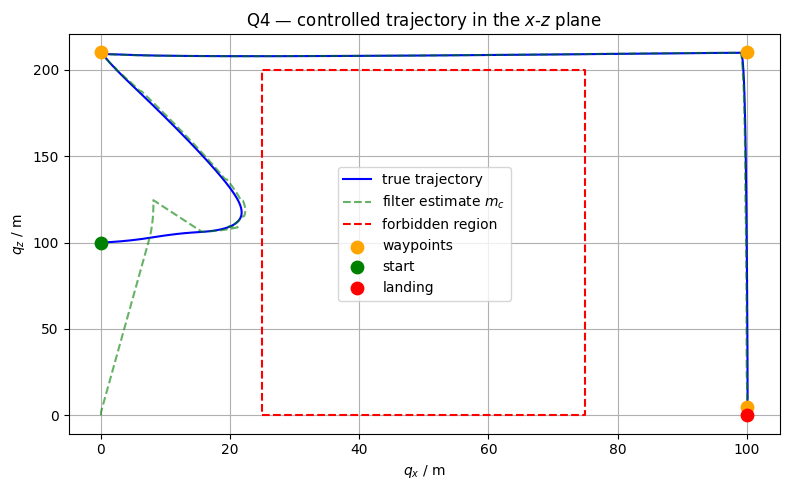

In [102]:
## Plot 1: controlled trajectory of the drone in the x-z plane.
# The true trajectory, filter estimate, forbidden box and landing are all marked.
fig, ax = plt.subplots(figsize = (8, 5))
ax.plot(states_q4[:, 0], states_q4[:, 1], color = "blue",  label = "true trajectory")
ax.plot(ests_q4[:, 0], ests_q4[:, 1], color = "green", linestyle = "--", alpha = 0.6, label = "filter estimate $m_c$")
ax.plot(forbidden_x, forbidden_z, color = "red", linestyle = "--", label = "forbidden region")

# Marking the waypoints and start and end points
wp_xy = np.array([[w[0], w[1]] for w in waypoints])
ax.scatter(wp_xy[:, 0], wp_xy[:, 1], s = 80, color = "orange", zorder = 5, label = "waypoints")
ax.scatter([states_q4[ 0, 0]], [states_q4[ 0, 1]], color = "green", zorder = 6, s = 80, label = "start")
ax.scatter([states_q4[-1, 0]], [states_q4[-1, 1]], color = "red",   zorder = 6, s = 80, label = "landing")

ax.set_xlabel("$q_x$ / m")
ax.set_ylabel("$q_z$ / m")
ax.set_title("Q4 — controlled trajectory in the $x$-$z$ plane")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

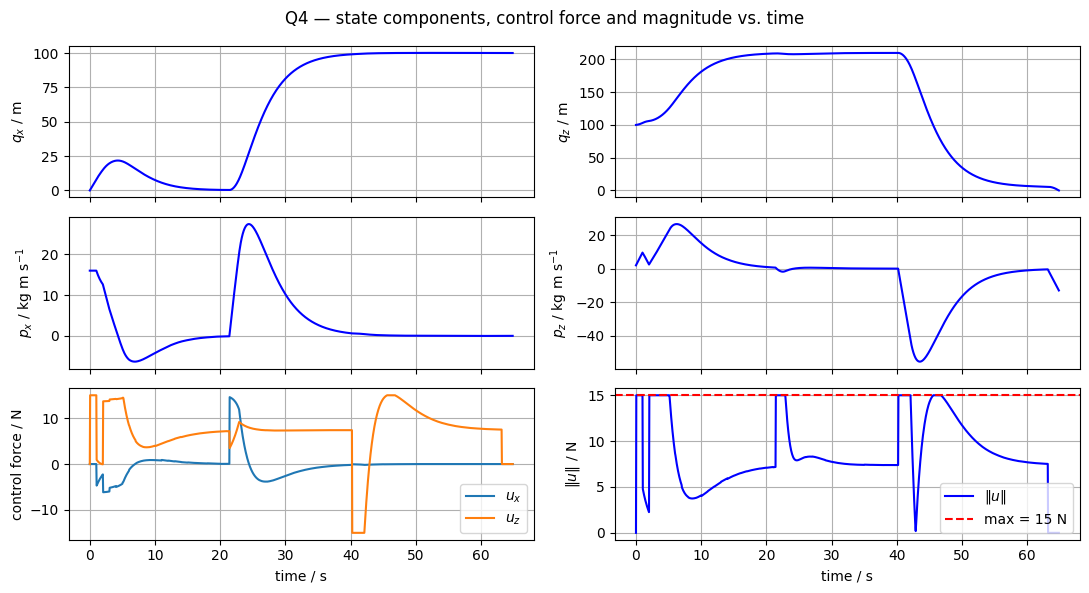

In [103]:
## Plot 2: displays the state components, control components and control magnitude against time.
## The dashed red line shows the 15N limit
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (11, 6), sharex = True)

ax[0, 0].plot(times_q4, states_q4[:, 0], color = "blue")
ax[0, 0].set_ylabel("$q_x$ / m")
ax[0, 0].grid()

ax[0, 1].plot(times_q4, states_q4[:, 1], color = "blue")
ax[0, 1].set_ylabel("$q_z$ / m")
ax[0, 1].grid()

ax[1, 0].plot(times_q4, states_q4[:, 2], color = "blue")
ax[1, 0].set_ylabel("$p_x$ / kg m s$^{-1}$")
ax[1, 0].grid()

ax[1, 1].plot(times_q4, states_q4[:, 3], color = "blue")
ax[1, 1].set_ylabel("$p_z$ / kg m s$^{-1}$")
ax[1, 1].grid()

ax[2, 0].plot(times_q4, controls_q4[:, 0], label = "$u_x$")
ax[2, 0].plot(times_q4, controls_q4[:, 1], label = "$u_z$")
ax[2, 0].set_ylabel("control force / N")
ax[2, 0].set_xlabel("time / s")
ax[2, 0].grid()
ax[2, 0].legend()

control_norm_q4 = np.linalg.norm(controls_q4, axis = 1)
ax[2, 1].plot(times_q4, control_norm_q4, color = "blue", label = r"$\|u\|$")
ax[2, 1].axhline(15.0, color = "red", linestyle = "--", label = "max = 15 N")
ax[2, 1].set_ylabel(r"$\|u\|$ / N")
ax[2, 1].set_xlabel("time / s")
ax[2, 1].grid()
ax[2, 1].legend()

fig.suptitle("Q4 — state components, control force and magnitude vs. time");
plt.tight_layout()
plt.show()

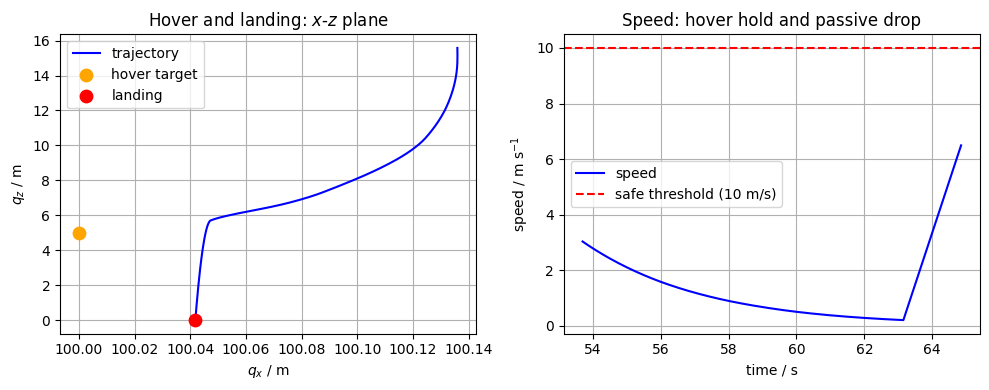

In [104]:
## Plot 3: zoomed view near the hover and landing phases.
## Left plot => x-z trajectory between hovering and landing.
## Right plot => speed of drone after hover till impact.
hover_idx = np.argmin(np.abs(states_q4[:, 0] - 100.0) + np.abs(states_q4[:, 1] - h_safe))
zoom_start = max(0, hover_idx - 200)

fig, ax = plt.subplots(1, 2, figsize = (10, 4))

# It lands 4cm horizontally from expected target
ax[0].plot(states_q4[zoom_start:, 0], states_q4[zoom_start:, 1],
           color = "blue", label = "trajectory")
ax[0].scatter([100.0], [h_safe], color = "orange", s = 80, zorder = 5, label = "hover target")
ax[0].scatter([states_q4[-1, 0]], [states_q4[-1, 1]],
              color = "red", s = 80, zorder = 5, label = "landing")
ax[0].set_xlabel("$q_x$ / m")
ax[0].set_ylabel("$q_z$ / m")
ax[0].set_title("Hover and landing: $x$-$z$ plane")
ax[0].grid()
ax[0].legend()

# Speed is less than 1 for over 5 seconds and then it free falls and has a velocity of 6m/s at impact
speed_zoom = np.linalg.norm(states_q4[zoom_start:, 2:] / m, axis = 1)
ax[1].plot(times_q4[zoom_start:], speed_zoom, color = "blue", label = "speed")
ax[1].axhline(10.0, color = "red", linestyle = "--", label = "safe threshold (10 m/s)")
ax[1].set_xlabel("time / s")
ax[1].set_ylabel("speed / m s$^{-1}$")
ax[1].set_title("Speed: hover hold and passive drop")
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

## Q4 — Discussion

The waypoints ensure the drone stays outside the forbidden region throughout the flight. The control input respects $\|u\| \leq 15$ N at all times — the limit is saturated during the initial climb but reduces as the position error decreases. Early estimation error from the Kalman filter causes minor deviations in the first few steps, but the filter converges quickly to ensure accurate control. The tight waypoint conditions ($<1$ m, $<0.5$ m s$^{-1}$) ensure the drone arrives at each waypoint with near-zero velocity, preventing instability when switching direction. After the 5 s hover, the drone falls freely and impacts at 6.49 m s$^{-1}$, well below the 10 m s$^{-1}$ threshold, confirming a safe landing.